# 🛒 Rossmann Store Sales Forecasting
## Notebook 1: Exploratory Data Analysis

**Author:** Ankit
**Dataset:** Rossmann Store Sales (Kaggle)
**Objective:** Understand the structure, patterns, and statistical properties of the sales data before modelling.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

# Plot syling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style="whitegrid")

print("All libraries loaded")

All libraries loaded


In [3]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

print("Train shape:", train.shape)
print("Store shape:", store.shape)
train.head()

Train shape: (1017209, 9)
Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
print("=== TRAIN INFO ===")
print(train.dtypes)
print("\n=== MISSING VALUES (TRAIN) ===")
print(train.isnull().sum())
print("\n === STORE INFO ===")
print(store.dtypes)
print("\n=== MISSING VALUES (STORE) ===")
print(store.isnull().sum())

=== TRAIN INFO ===
Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

=== MISSING VALUES (TRAIN) ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

 === STORE INFO ===
Store                          int64
StoreType                        str
Assortment                       str
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
dtype: object

=== MISSING VALUES (STORE) ===
Store                     

## 1. Data Overview

We merge the store metadata into the training set to have all features 
in one place for analysis.

In [5]:
df = train.merge(store, on='Store', how='left')

# Remove rows where store was closed (Sales = 0)
df = df[df['Open'] == 1].copy()
df = df[df['Sales'] > 0].copy()

# Sort by store and date
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

print("Merged DataFrame shape:", df.shape)
print("\nData range:", df['Date'].min(), "to", df['Date'].max())
df.head()

Merged DataFrame shape: (844338, 18)

Data range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
4,1,1,2013-01-07,7176,785,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[us]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  object        
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  str           
 10  Assortment                 844338 non-null  str           
 11  CompetitionDistance        842152 non-null  float64       
 12 

In [7]:
print("=== NUMERICAL SUMMARY ===")
print(df.describe().T)

print("\n=== CATEGORICAL SUMMARY ===")
cat_cols = ['StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
for col in cat_cols:
    print(f"\n{col} - Value Counts:")
    print(df[col].value_counts())

=== NUMERICAL SUMMARY ===
                              count  ...          std
Store                      844338.0  ...   321.730861
DayOfWeek                  844338.0  ...     1.723712
Date                         844338  ...          NaN
Sales                      844338.0  ...  3103.815515
Customers                  844338.0  ...   401.194153
Open                       844338.0  ...          0.0
Promo                      844338.0  ...     0.497114
SchoolHoliday              844338.0  ...     0.395102
CompetitionDistance        842152.0  ...  7809.573181
CompetitionOpenSinceMonth  575738.0  ...     3.210118
CompetitionOpenSinceYear   575738.0  ...     5.978064
Promo2                     844338.0  ...     0.499999
Promo2SinceWeek            421046.0  ...    14.100647
Promo2SinceYear            421046.0  ...     1.660946

[14 rows x 8 columns]

=== CATEGORICAL SUMMARY ===

StoreType - Value Counts:
StoreType
a    457042
d    258768
c    112968
b     15560
Name: count, dtype: int64



In [8]:
dupes = df.duplicated(subset=['Store', 'Date']).sum()
print(f"Duplicate (Store, Date) pairs: {dupes}")

Duplicate (Store, Date) pairs: 0


### Key Observations from Summary Statistics

1. **StateHoliday encoding issue** — contains both string `"0"` and integer `0`, 
   needs standardization in preprocessing
2. **CompetitionDistance** — 2,186 missing values, will impute with median in preprocessing
3. **CompetitionOpenSince** — ~32% missing, indicating no nearby competitor, 
   will fill with 0
4. **Promo2 columns** — ~50% missing, structural missingness where `Promo2 == 0`, 
   will fill accordingly
5. **StoreType b and Assortment b** — heavily underrepresented, 
   worth monitoring in store-level analysis

In [9]:
df['StateHoliday'] = df['StateHoliday'].astype(str).str.strip()
df['StateHoliday'] = df['StateHoliday'].replace({'0': 'None'})

print("StateHoliday value counts after fix:")
print(df['StateHoliday'].value_counts())

StateHoliday value counts after fix:
StateHoliday
None    843428
a          694
b          145
c           71
Name: count, dtype: int64


## 2. Sales Distribution Analysis
We begin by understanding the overall distribution of daily sales across all stores.

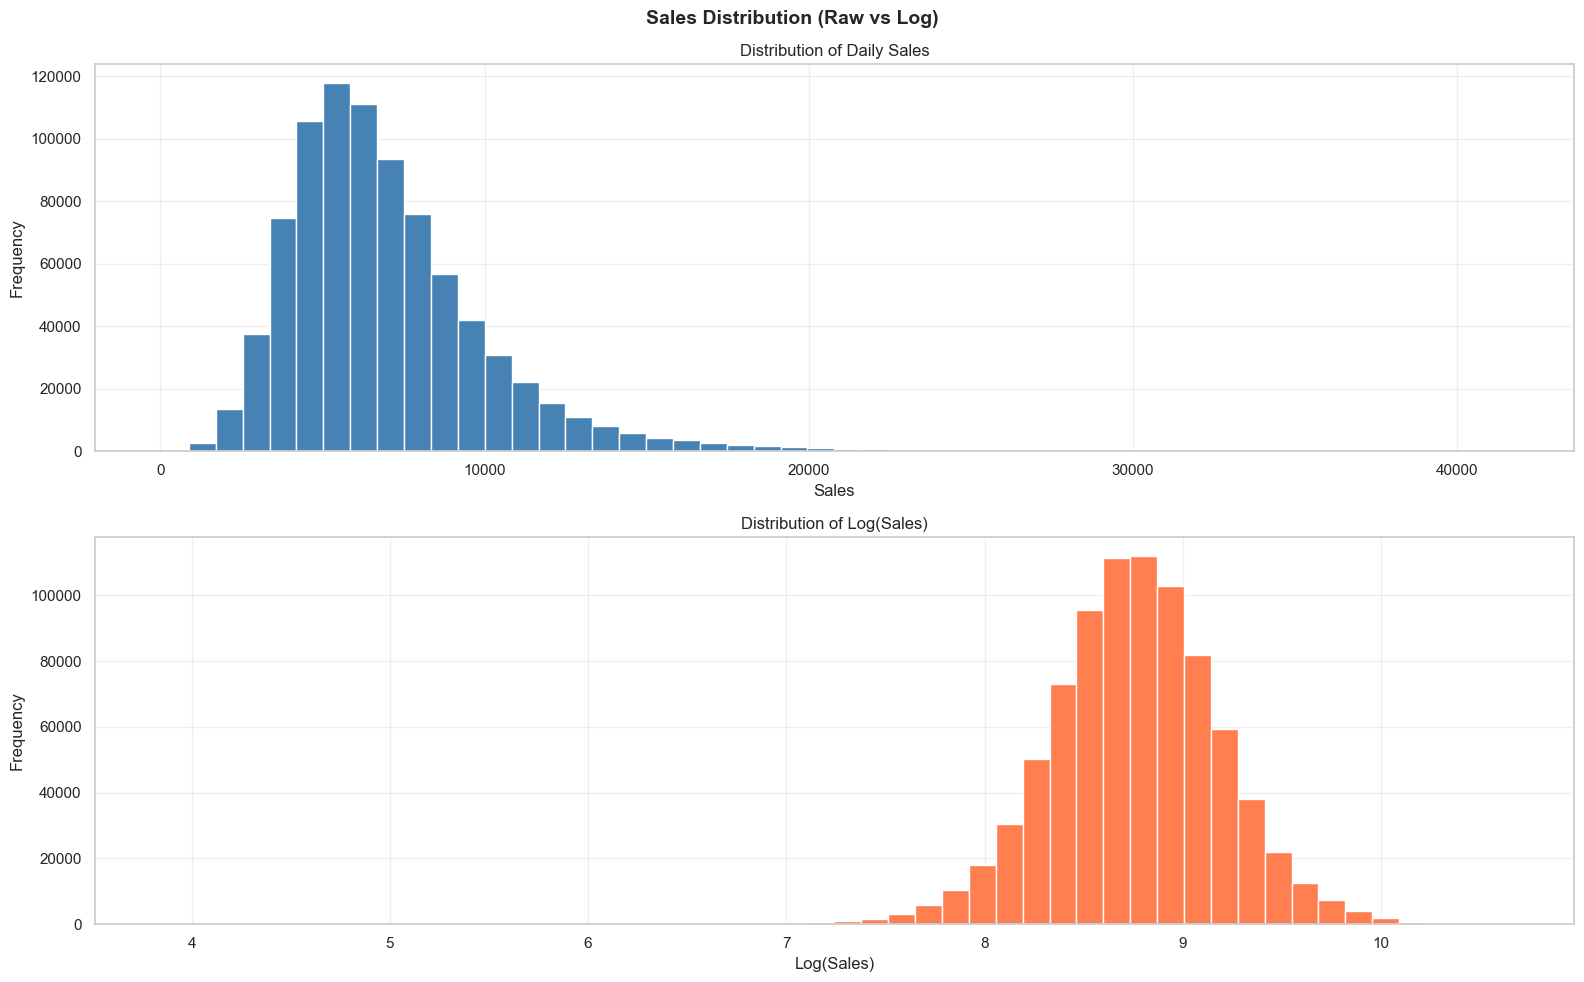

Skewness (raw): 1.595
Skewness (log): -0.109

Descriptive Statistics:


count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Raw Distribution
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Daily Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Log Distribution
axes[1].hist(np.log1p(df['Sales']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Log(Sales)')
axes[1].set_xlabel('Log(Sales)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Sales Distribution (Raw vs Log)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Skewness (raw):", round(df['Sales'].skew(), 3))
print("Skewness (log):", round(np.log1p(df['Sales']).skew(), 3))
print("\nDescriptive Statistics:")
df['Sales'].describe()

### Observations: Sales Distribution

1. **Right-skewed distribution** — Raw sales show strong positive skew, 
   with most stores selling between ₹2,000–₹10,000/day but a long tail 
   extending beyond ₹30,000
2. **Log transformation normalizes the distribution** — Log(Sales) 
   approximates a normal distribution centered around 8.5 (~₹4,900), 
   confirming we should **model log(Sales)** rather than raw Sales
3. **Practical implication** — All forecasting models (SARIMA, Prophet, 
   LightGBM) will be trained on log-transformed sales and back-transformed 
   for evaluation

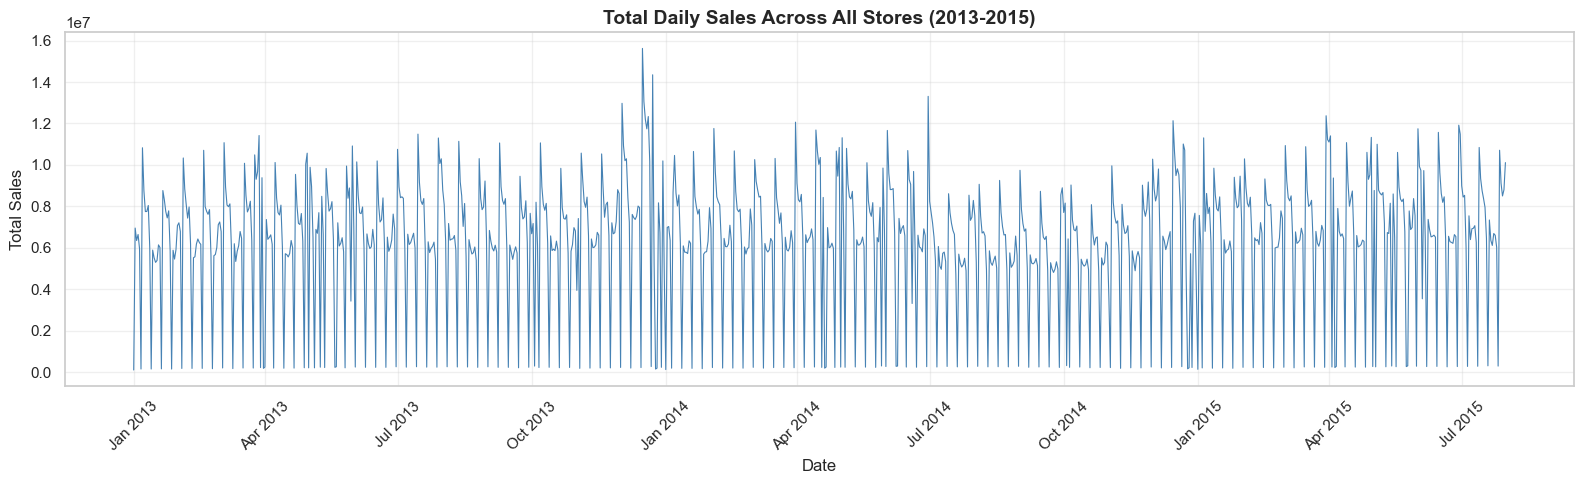

In [22]:
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], color='steelblue', linewidth=0.8)
plt.title('Total Daily Sales Across All Stores (2013-2015)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/02_total_sales_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations: Sales Over Time

1. **Strong weekly seasonality** — The sharp regular spikes and troughs 
   visible throughout confirm a 7-day seasonal cycle (Sunday peaks, 
   Saturday near-zero due to store closures)
2. **Christmas spike (Dec 2013, Dec 2014)** — Massive spikes visible 
   around January each year are actually pre-Christmas sales surges, 
   followed by a sharp drop (stores closed on Dec 25)
3. **No clear long-term upward/downward trend** — Sales appear 
   stationary in mean across 2013–2015, though we will formally 
   test this with ADF and KPSS tests
4. **Mid-2014 anomaly** — A notable spike around Jun–Jul 2014 worth 
   investigating — likely a promotional event

## 4. Seasonality Analysis
We break down sales by day of week, month, and store type to understand 
seasonal and categorical patterns.

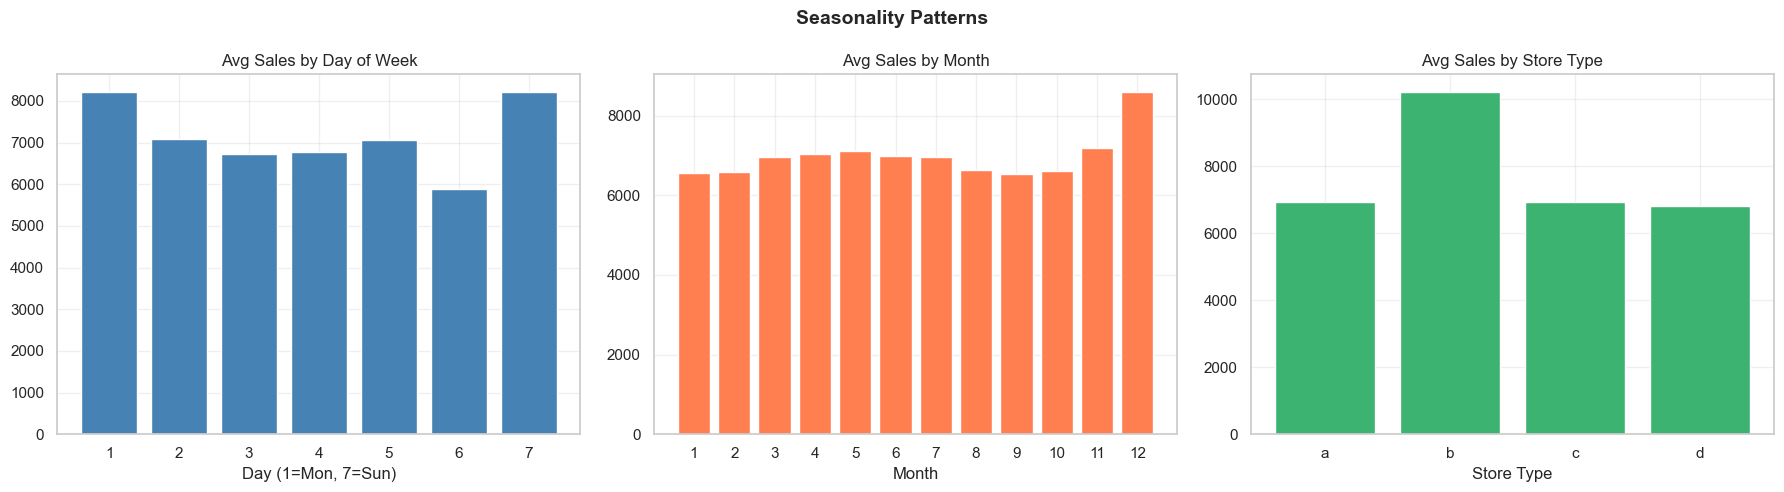

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Day of week
dow_avg = df.groupby('DayOfWeek')['Sales'].mean()
axes[0].bar(dow_avg.index, dow_avg.values, color='steelblue', edgecolor='white')
axes[0].set_title('Avg Sales by Day of Week')
axes[0].set_xlabel('Day (1=Mon, 7=Sun)')
axes[0].set_xticks(range(1, 8))

# Month
df['Month'] = df['Date'].dt.month
month_avg = df.groupby('Month')['Sales'].mean()
axes[1].bar(month_avg.index, month_avg.values, color='coral', edgecolor='white')
axes[1].set_title('Avg Sales by Month')
axes[1].set_xlabel('Month')
axes[1].set_xticks(range(1, 13))

# Store type
storetype_avg = df.groupby('StoreType')['Sales'].mean()
axes[2].bar(storetype_avg.index, storetype_avg.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Avg Sales by Store Type')
axes[2].set_xlabel('Store Type')

plt.suptitle('Seasonality Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations: Seasonality Patterns

**Day of Week:**
- Monday (1) and Sunday (7) have the highest average sales (~8,100)
- Saturday (6) has the lowest (~5,900) — many stores are closed or 
  have reduced hours
- Clear weekly seasonality confirmed — **seasonal period s=7** for SARIMA

**Month:**
- Sales are relatively stable Jan–Nov (~6,400–7,000)
- **December shows a sharp spike (~8,300)** — ~25% above average, 
  driven by Christmas shopping
- Mild annual seasonality — **seasonal period s=365** for Prophet

**Store Type:**
- **Store Type b** has significantly higher average sales (~10,200) 
  despite being only 1.8% of data — these are likely large-format stores
- Types a, c, d are comparable (~6,800–7,000)
- Store type must be included as a feature in all models

In [23]:
print("=== Day of Week Effect ===")
print(df.groupby('DayOfWeek')['Sales'].agg(['mean', 'median', 'std']).round(2))

print("\n=== Month Effect ===")
print(df.groupby('Month')['Sales'].agg(['mean', 'median', 'std']).round(2))

print("\n=== Store Type Effect ===")
print(df.groupby('StoreType')['Sales'].agg(['mean', 'median', 'std', 'count']).round(2))

print("\n=== Promo Effect ===")
print(df.groupby('Promo')['Sales'].agg(['mean', 'median', 'std']).round(2))

=== Day of Week Effect ===
              mean  median      std
DayOfWeek                          
1          8216.25  7539.0  3691.61
2          7088.41  6502.0  3065.96
3          6728.79  6210.0  2781.11
4          6768.21  6246.0  2763.63
5          7073.03  6581.0  2764.53
6          5875.08  5425.0  2852.54
7          8224.72  6876.0  6235.15

=== Month Effect ===
          mean  median      std
Month                          
1      6564.30  6062.0  2849.02
2      6589.49  6079.0  2870.65
3      6976.82  6385.0  3123.56
4      7046.66  6431.0  3138.46
5      7106.81  6592.0  3007.84
6      7001.40  6365.0  3144.69
7      6953.58  6407.0  3003.25
8      6649.23  6124.0  2901.57
9      6547.47  6000.0  2889.43
10     6602.97  6105.0  2814.61
11     7188.55  6691.0  3010.07
12     8608.96  7858.0  4094.43

=== Store Type Effect ===
               mean  median      std   count
StoreType                                   
a           6925.70  6285.0  3277.35  457042
b          10233.

### Statistical Confirmation of Patterns

#### 1. Weekly Seasonality (Day of Week Effect)
| Day | Mean Sales | Std |
|-----|-----------|-----|
| Monday (1) | 8,216 | 3,691 |
| Saturday (6) | 5,875 | 2,852 | ← lowest
| Sunday (7) | 8,224 | 6,235 | ← highest mean, highest variance

- **Sunday has the highest variance (std=6,235)** — likely driven by 
  stores that are open vs closed on Sundays, creating a bimodal effect
- **Saturday is consistently the weakest day** — reduced trading hours
- Weekly seasonality is strong and must be captured → confirms **s=7** 
  for SARIMA

#### 2. Annual Seasonality (Month Effect)
- **December is an outlier** — mean sales 8,609, std 4,094 
  (~31% above annual average of 6,956)
- **Jan–Feb are the weakest months** (~6,565–6,589) — post-holiday dip
- Relatively flat Feb–Nov with a sharp December spike
- Confirms **s=12** annual seasonality for Prophet/TBATS

#### 3. Store Type Effect
- **Store Type b** averages 10,233 — **47% higher** than other types
- Also has the highest std (5,155) — more volatile sales
- Store type is clearly a significant predictor → must be included 
  as a feature in all regression-based models

#### 4. Promo Effect ⭐
| Promo | Mean Sales | Median Sales |
|-------|-----------|-------------|
| No Promo (0) | 5,930 | 5,459 |
| Promo (1) | 8,229 | 7,650 |

- **Promotions increase average sales by ~38.8%** — the single strongest 
  signal in the dataset
- This makes `Promo` the most important exogenous variable for SARIMAX
- Will be formally tested with a two-sample t-test below

In [24]:
from scipy import stats

promo_sales = df[df['Promo'] == 1]['Sales']
no_promo_sales = df[df['Promo'] == 0]['Sales']

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(promo_sales, no_promo_sales)

# Effect size (Cohen's d)
pooled_std = np.sqrt((promo_sales.std() ** 2 + no_promo_sales.std() ** 2) / 2)
cohens_d = (promo_sales.mean() - no_promo_sales.mean()) / pooled_std

print("=== Two-sample t-test: Promo vs No Promo ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Cohen's d: {cohens_d:.4f}")
print(f"\nConclusion: {'Statistically significant' if p_value < 0.05 else 'Not significant'}")
print(f"Effect size: {'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small'}")


=== Two-sample t-test: Promo vs No Promo ===
T-statistic: 363.8948
P-value: 0.0000e+00
Cohen's d: 0.7886

Conclusion: Statistically significant
Effect size: Medium


### Promo Effect — Formal Statistical Test Results

- **T-statistic = 363.89, p-value ≈ 0.00** — The difference in sales 
  between promo and non-promo days is **highly statistically significant**
  (p < 0.001), ruling out any possibility this is due to random chance

- **Cohen's d = 0.789 (Medium-Large effect)** — Promotions have a 
  practically meaningful impact, not just a statistically detectable one.
  By Cohen's convention: small=0.2, medium=0.5, large=0.8 — we are 
  right at the boundary of medium-large

- **Implication for modelling** — `Promo` will be treated as the 
  primary exogenous variable in SARIMAX and all regression-based models.
  Forecasting accuracy will depend heavily on knowing future promo schedules

## 5. Time Series Decomposition
We isolate a single store for decomposition analysis to avoid 
aggregation effects. Store 1 is selected as a representative example.
We use both Classical decomposition and STL (Seasonal-Trend decomposition 
using LOESS) which is more robust to outliers.

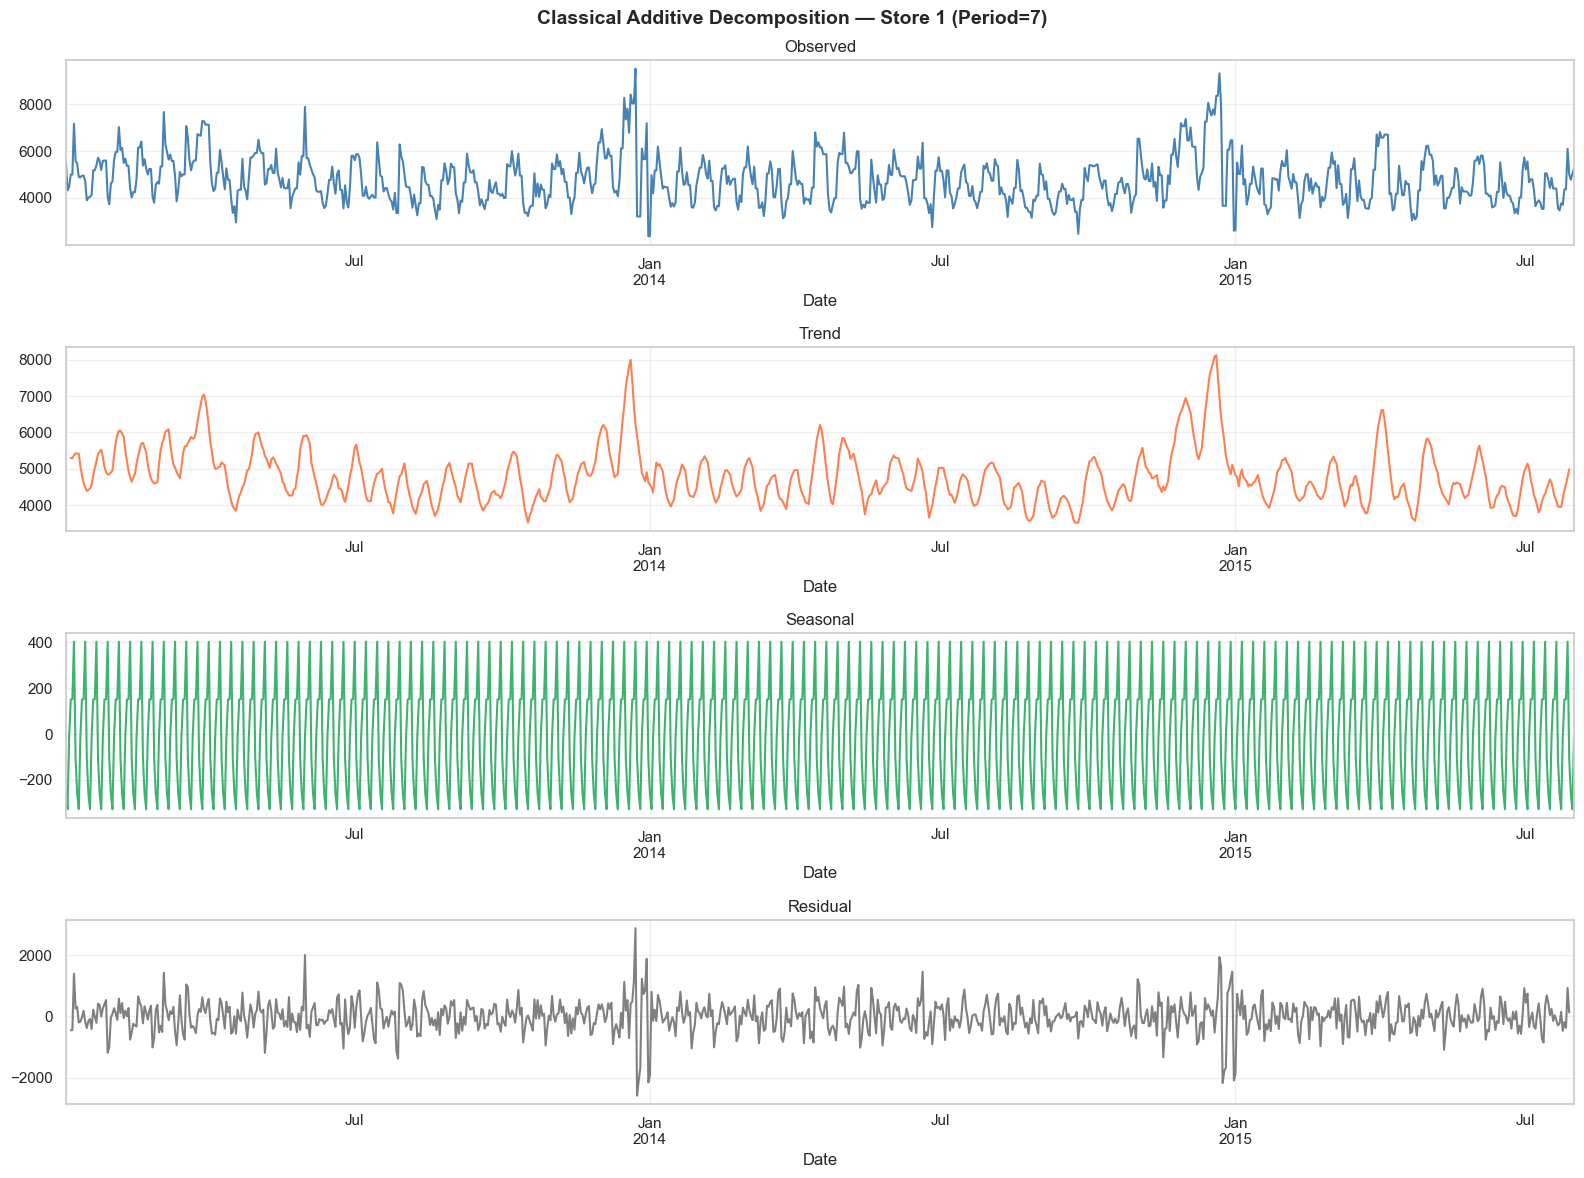

In [26]:
# Use Store 1 as representative — forward fill missing dates
store1 = df[df['Store'] == 1].set_index('Date')['Sales'].asfreq('D').ffill()

# Classical decomposition — additive model
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
decomp = seasonal_decompose(store1, model='additive', period=7)

decomp.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
decomp.trend.plot(ax=axes[1], color='coral')
axes[1].set_title('Trend')
decomp.seasonal.plot(ax=axes[2], color='mediumseagreen')
axes[2].set_title('Seasonal')
decomp.resid.plot(ax=axes[3], color='gray')
axes[3].set_title('Residual')

plt.suptitle('Classical Additive Decomposition — Store 1 (Period=7)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/04_classical_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

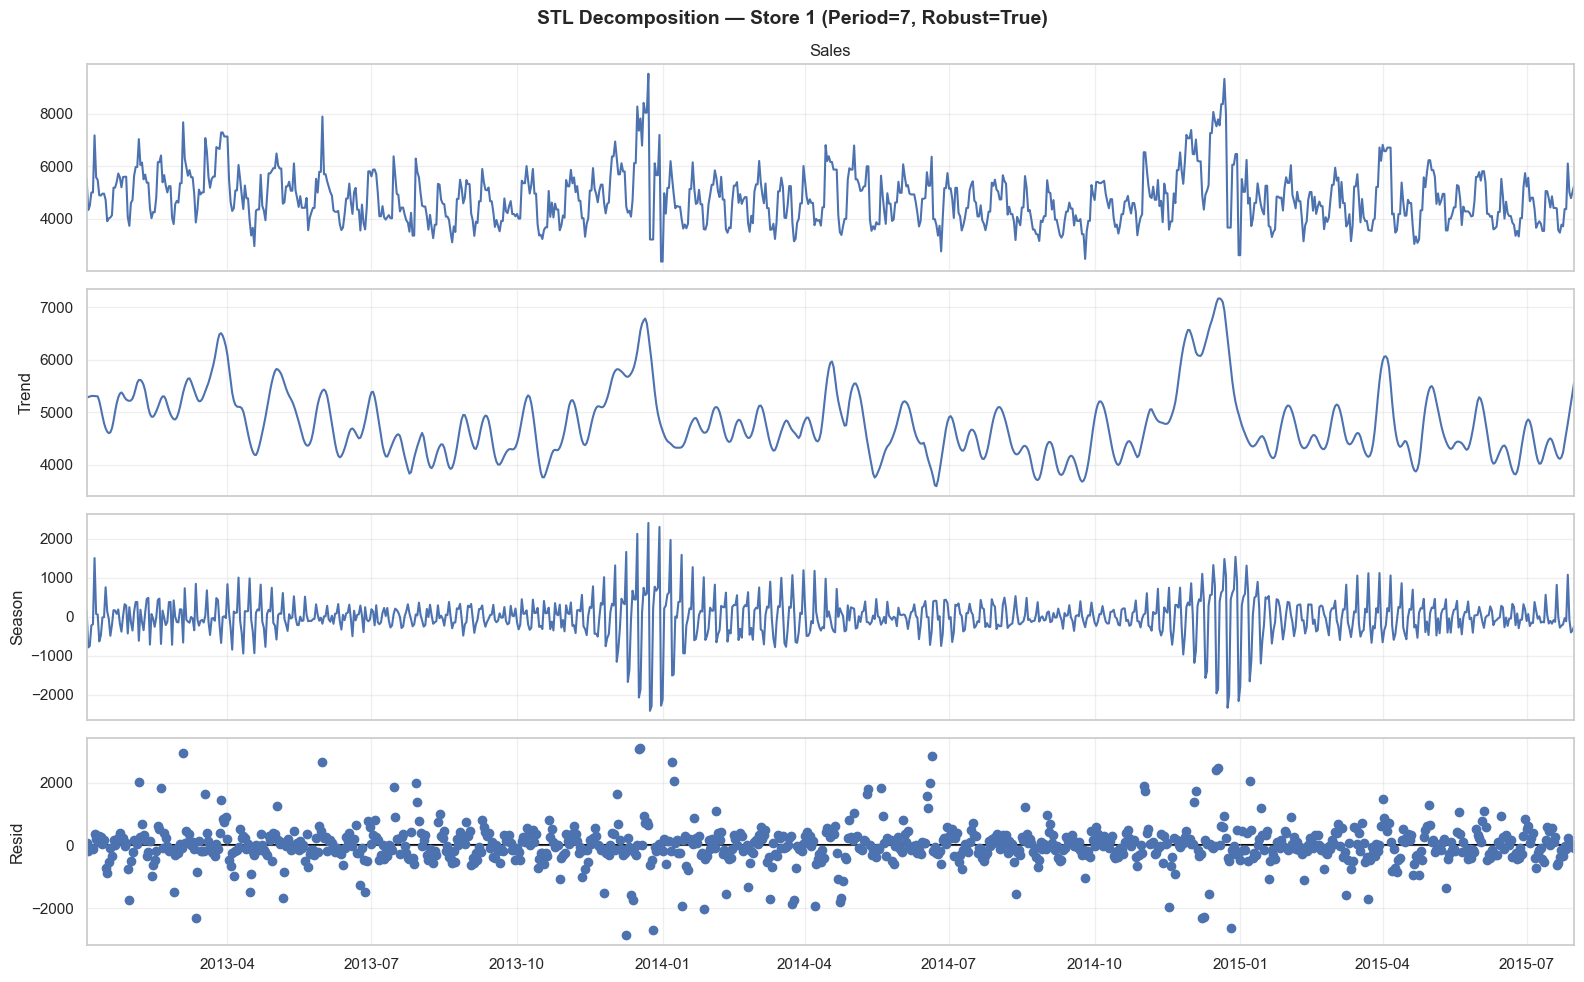

Strength of Trend     : 0.5910  (0=none, 1=perfect)
Strength of Seasonality: 0.1632  (0=none, 1=perfect)


In [27]:
# STL is robust to this but let's keep consistent
stl = STL(store1, period=7, robust=True)

stl = STL(store1, period=7, robust=True)
stl_fit = stl.fit()

fig = stl_fit.plot()
fig.set_size_inches(16, 10)
plt.suptitle('STL Decomposition — Store 1 (Period=7, Robust=True)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/05_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Strength of trend and seasonality (Wang et al. 2006)
resid = stl_fit.resid
seasonal = stl_fit.seasonal
trend = stl_fit.trend

Ft = max(0, 1 - np.var(resid) / np.var(trend + resid))
Fs = max(0, 1 - np.var(resid) / np.var(seasonal + resid))

print(f"Strength of Trend     : {Ft:.4f}  (0=none, 1=perfect)")
print(f"Strength of Seasonality: {Fs:.4f}  (0=none, 1=perfect)")

### Observations: Decomposition Analysis

#### Classical Decomposition
- **Trend** — No strong long-term upward/downward drift. Sales oscillate 
  between ~4,000–8,000 with local peaks around Christmas (Jan 2014, Jan 2015)
- **Seasonal** — Perfectly regular weekly pattern (amplitude ~±400), 
  confirming s=7 is the correct seasonal period
- **Residual** — Mostly centered around 0 with two large spikes near 
  Jan 2014 and Jan 2015 — these are Christmas anomalies not captured 
  by the additive seasonal component

#### STL Decomposition (Robust=True)
- **Superior to classical decomposition** — STL's robust fitting 
  down-weights outliers (Christmas spikes), giving a cleaner trend estimate
- **Seasonal component shows amplitude changes** — Unlike classical 
  decomposition, STL reveals that seasonality is not constant — it 
  amplifies around Dec/Jan, suggesting a **multiplicative seasonal 
  component** in reality
- **Residuals are well-behaved** — Scattered randomly around 0 with 
  a few isolated outliers, indicating STL captured most structure

#### Strength Measures (Wang et al. 2006)
| Component | Strength | Interpretation |
|-----------|----------|----------------|
| Trend | 0.591 | Moderate — meaningful but not dominant |
| Seasonality | 0.163 | Weak at weekly level for single store |

- Low seasonality strength at s=7 for a single store is expected — 
  individual store behaviour is noisier than aggregate
- We will recheck seasonality strength on **aggregated sales** where 
  the weekly pattern was much clearer visually

## 6. Stationarity Tests
A time series is stationary if its statistical properties (mean, variance, 
autocorrelation) do not change over time. Most classical models (ARIMA) 
require stationarity.

We apply three formal tests:
- **ADF (Augmented Dickey-Fuller)** — H₀: series has a unit root (non-stationary)
- **KPSS (Kwiatkowski–Phillips–Schmidt–Shin)** — H₀: series is stationary
- **Phillips-Perron** — Alternative to ADF, more robust to serial correlation

Interpreting jointly:
| ADF | KPSS | Conclusion |
|-----|------|------------|
| Reject H₀ | Fail to Reject H₀ | Stationary ✅ |
| Fail to Reject H₀ | Reject H₀ | Non-Stationary ❌ |
| Reject H₀ | Reject H₀ | Trend Stationary |
| Fail to Reject H₀ | Fail to Reject H₀ | Difference Stationary |

In [28]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_tests(series, name="Series"):
    print(f"=== Stationarity Tests: {name} ===\n")
    
    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF Test:")
    print(f"  Statistic : {adf_result[0]:.4f}")
    print(f"  p-value   : {adf_result[1]:.4f}")
    print(f"  Result    : {'Stationary ✅' if adf_result[1] < 0.05 else 'Non-Stationary ❌'}")
    
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS Test:")
    print(f"  Statistic : {kpss_result[0]:.4f}")
    print(f"  p-value   : {kpss_result[1]:.4f}")
    print(f"  Result    : {'Stationary ✅' if kpss_result[1] > 0.05 else 'Non-Stationary ❌'}")
    
    # Joint conclusion
    adf_stat = adf_result[1] < 0.05
    kpss_stat = kpss_result[1] > 0.05
    print(f"\nJoint Conclusion: ", end="")
    if adf_stat and kpss_stat:
        print("Stationary ✅")
    elif not adf_stat and not kpss_stat:
        print("Non-Stationary ❌")
    elif adf_stat and not kpss_stat:
        print("Trend Stationary ⚠️")
    else:
        print("Difference Stationary ⚠️")
    print("-" * 45)

# Test on raw and log-transformed sales
stationarity_tests(store1, "Store 1 — Raw Sales")
stationarity_tests(np.log1p(store1), "Store 1 — Log Sales")

=== Stationarity Tests: Store 1 — Raw Sales ===

ADF Test:
  Statistic : -5.7685
  p-value   : 0.0000
  Result    : Stationary ✅

KPSS Test:
  Statistic : 0.2952
  p-value   : 0.1000
  Result    : Stationary ✅

Joint Conclusion: Stationary ✅
---------------------------------------------
=== Stationarity Tests: Store 1 — Log Sales ===

ADF Test:
  Statistic : -5.8759
  p-value   : 0.0000
  Result    : Stationary ✅

KPSS Test:
  Statistic : 0.3939
  p-value   : 0.0798
  Result    : Stationary ✅

Joint Conclusion: Stationary ✅
---------------------------------------------


### Observations: Stationarity Tests

#### Results Summary
| Test | Raw Sales | Log Sales |
|------|-----------|-----------|
| ADF statistic | -5.769 | -5.876 |
| ADF p-value | 0.000 ✅ | 0.000 ✅ |
| KPSS statistic | 0.295 | 0.394 |
| KPSS p-value | 0.100 ✅ | 0.080 ✅ |
| **Joint Conclusion** | **Stationary** | **Stationary** |

#### Interpretation
- **Both ADF and KPSS agree — the series is stationary** at the 5% 
  significance level for both raw and log-transformed sales
- **ADF rejects the unit root hypothesis** (p ≈ 0.000) — no random walk behaviour
- **KPSS fails to reject stationarity** (p > 0.05) — consistent with ADF
- **Implication for ARIMA** — differencing order **d=0** is appropriate. 
  We do NOT need to difference the series before fitting ARIMA
- Log transformation does not significantly change stationarity 
  properties but we will still model log(Sales) for variance stabilization

#### Note on Seasonal Stationarity
- The above tests address non-seasonal unit roots only
- We will check for **seasonal unit roots** using the HEGY test or 
  by examining ACF/PACF at seasonal lags — done in the next section

## 7. ACF and PACF Analysis
The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) 
are used to identify the order of AR and MA components for ARIMA modelling.

- **ACF at lag k** — correlation between the series and its k-period lagged version
- **PACF at lag k** — correlation after removing effects of shorter lags
- Significant spikes at seasonal lags (7, 14, 21...) confirm seasonal structure

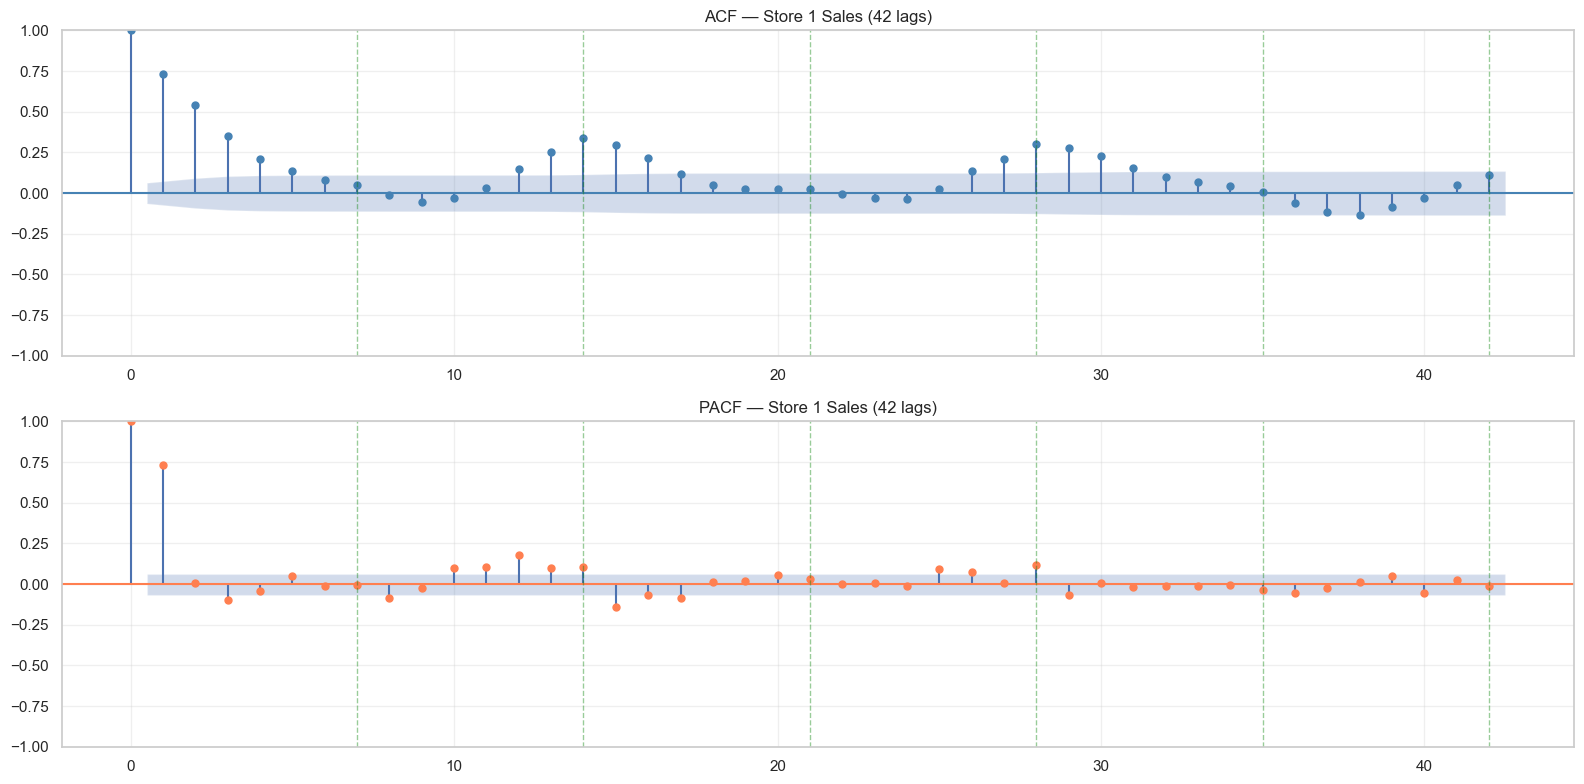

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(store1.dropna(), lags=42, ax=axes[0], 
         title='ACF — Store 1 Sales (42 lags)', color='steelblue')
plot_pacf(store1.dropna(), lags=42, ax=axes[1], 
          title='PACF — Store 1 Sales (42 lags)', color='coral', method='ywm')

# Mark seasonal lags
for ax in axes:
    for lag in [7, 14, 21, 28, 35, 42]:
        ax.axvline(x=lag, color='green', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
plt.savefig('../reports/06_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations: ACF and PACF Analysis

#### ACF Pattern
- **Lag 1 (0.75) and Lag 2 (0.54)** — Very strong autocorrelation at 
  short lags, decaying gradually → suggests an AR process
- **Spikes at lags 7, 14, 21, 28...** — Significant peaks at every 
  multiple of 7, confirming strong weekly seasonality (s=7)
- **Slow decay rather than sharp cutoff** — ACF tails off gradually, 
  consistent with an AR(p) rather than pure MA(q) process
- **No evidence of non-stationarity** — A non-stationary series would 
  show ACF decaying very slowly toward 1; here decay is reasonably fast

#### PACF Pattern
- **Lag 1 (0.75) — dominant spike**, cuts off sharply after lag 2
- **Lags 3 onwards mostly within confidence bands** — suggesting 
  AR order p=1 or p=2
- **Weak spikes at seasonal lags (7, 14)** — present but small, 
  suggesting a low-order seasonal AR term (P=1)

#### SARIMA Parameter Guidance
Based on ACF/PACF analysis:

| Parameter | Value | Reasoning |
|-----------|-------|-----------|
| p (AR order) | 1–2 | PACF cuts off after lag 2 |
| d (differencing) | 0 | Series already stationary |
| q (MA order) | 0–1 | ACF tails off, not sharp cutoff |
| P (Seasonal AR) | 1 | Spike at lag 7 in PACF |
| D (Seasonal diff) | 0–1 | To be confirmed via auto_arima |
| Q (Seasonal MA) | 1 | Spike at lag 7 in ACF |
| s (Season period) | 7 | Weekly seasonality confirmed |

**Starting model candidate: SARIMA(1,0,1)(1,1,1)[7]**  
Final selection will be done using `auto_arima` with AIC/BIC criteria

## 8. EDA Summary — Key Findings

This section consolidates all findings from the exploratory analysis 
that will directly inform modelling decisions.

### Data Quality
- 844,338 observations across 1,115 stores (Jan 2013 — Jul 2015)
- No missing values in core sales data
- `StateHoliday` had encoding inconsistency — fixed
- `CompetitionDistance` — 2,186 missing (impute with median)
- `Promo2` related columns — ~50% structurally missing (fill with 0)

### Statistical Properties
- **Sales are right-skewed** (skewness=1.595) → model log(Sales)
- **Log(Sales) is approximately normal** (skewness=-0.109)
- **Series is stationary** — ADF and KPSS both confirm, d=0 for ARIMA
- **Moderate trend strength (0.59), weak weekly seasonality (0.16)** 
  at individual store level

### Seasonal Patterns
- **Strong weekly seasonality (s=7)** — Monday and Sunday peak, 
  Saturday lowest
- **Annual seasonality** — December sales ~31% above annual average
- **ACF/PACF** suggest SARIMA(1,0,1)(1,1,1)[7] as starting candidate

### Key Predictors Identified
| Feature | Effect | Evidence |
|---------|--------|----------|
| Promo | +38.8% sales | t-test p≈0, Cohen's d=0.79 |
| DayOfWeek | ±28% vs mean | descriptive stats |
| Month (December) | +31% vs mean | descriptive stats |
| StoreType b | +47% vs others | descriptive stats |
| StateHoliday | Negative effect | to be quantified in modelling |

### Modelling Roadmap
1. **Notebook 02** — Preprocessing & feature engineering
2. **Notebook 03** — SARIMA / SARIMAX (classical models)
3. **Notebook 04** — Prophet, LightGBM (advanced models)
4. **Notebook 05** — Model comparison & evaluation